# Phase 1 — 曲線：点列からB-splineへ（答案）

[本文](../../docs/cad/texts/phase1-curves.md) / [学習ログ](../../docs/cad/learning-log.md) / [ロードマップ](../../docs/cad/ROADMAP.md)

目的：Bézier曲線とB-spline曲線を自作コードで評価し、重みの性質（1の分割・非負・局所台）とノットの多重度から、曲線の性質を数値で確かめる。最後にSTEPの `B_SPLINE_CURVE_WITH_KNOTS` を自分で評価する。

## 提出と採点の範囲

- 5問・100点。記述・式・コードをこのNotebookにまとめる。目安は2〜3回に分けて合計2〜4時間。
- 本文の定義・式（Cox–de Boorの漸化式、導関数の式、ノット挿入の式）は既知として利用可。証明・再導出は不要。
- 定型の入力検査、スパン探索、描画、Bernstein形式の評価は先頭セルで配布する。**実装するのは各問の `TODO` の関数と、指定された検証実験**。
- `_ref` の付いた変数は配布実験用の値。関数は**引数だけ**から計算し、`_ref` を関数内で参照しない。実験セルで `_ref` を使うのは可。
- 比較の許容値は、座標の大きさ $s=\max(1,\max_i\|\mathbf P_i\|_2)$ に対する相対値で指定する（配布関数 `scale_of(P)`）。
- 未実装の関数は `NotImplementedError` のまま残してよい。配布チェックは未実装ならその旨を表示する。**エラーなく全セルが動くことと、答案が完成したことは別。**
- 図は任意。形の確認に使うと、幾何の性質を「見て」確かめられる（`plot_curve` を配布）。採点は指定した数値と記述で行う。

| 演習 | 内容 | 点 |
| --- | --- | --- |
| 1 | Bézier曲線とde Casteljau | 15 |
| 2 | Cox–de Boorの評価器とSTEPの曲線 | 30 |
| 3 | 1次B-splineとFEMの形状関数 | 20 |
| 4 | 多重度と連続性、$C^k$ と $G^k$ | 20 |
| 5 | ノット挿入と形状の同一性 | 15 |

## Google Colabで解く場合

このPhaseはNumPyとmatplotlibだけを使うため、追加のインストールは不要。

1. Colabの「ファイル → ノートブックをアップロード」で、このファイル（`notebooks/cad/Phase1.ipynb`）を開く。
2. 解答後、「ファイル → ダウンロード → .ipynb をダウンロード」で保存し、リポジトリの同じパスへ上書きする。
3. ブランチがGitHubへpushされていれば、`https://colab.research.google.com/github/meshitaro0/cae-lab/blob/<ブランチ名>/notebooks/cad/Phase1.ipynb` から直接開き、「ファイル → GitHubにコピーを保存」で戻すこともできる。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

# ---- 配布する入力検査・補助関数。ここを再実装する課題ではない。 ----
def check_points(P):
    """制御点を (個数, 次元) の有限な配列として返す。次元は2または3、個数は2以上。"""
    P = np.asarray(P, dtype=float)
    if P.ndim != 2 or P.shape[0] < 2 or P.shape[1] not in (2, 3) or not np.all(np.isfinite(P)):
        raise ValueError("制御点は (個数>=2, 次元=2または3) の有限な配列です")
    return P

def check_knot_vector(U, p, n_ctrl):
    """開ノットベクトルとして妥当か確かめる。ノット数 = 制御点数 + 次数 + 1。"""
    U = np.asarray(U, dtype=float)
    if not (isinstance(p, (int, np.integer)) and p >= 0):
        raise ValueError("次数pは0以上の整数です（0次は導関数曲線で現れる）")
    if U.ndim != 1 or len(U) != n_ctrl + p + 1:
        raise ValueError(f"ノット数は制御点数+次数+1 = {n_ctrl + p + 1} 個が必要です（現在 {len(U)} 個）")
    if not np.all(np.isfinite(U)) or np.any(np.diff(U) < 0):
        raise ValueError("ノットベクトルは有限な非減少列です")
    if np.any(U[:p + 1] != U[0]) or np.any(U[-p - 1:] != U[-1]) or U[0] == U[-1]:
        raise ValueError("両端のノットは p+1 重の開ノットベクトルとします")
    return U

def scale_of(P):
    """許容値の基準 s = max(1, max_i ||P_i||_2)。"""
    return max(1.0, float(np.max(np.linalg.norm(np.asarray(P, float), axis=1))))

def find_span(U, p, u):
    """u_j <= u < u_{j+1} を満たすスパン番号 j。右端 u = U[-1] では最後の非退化区間を返す。"""
    U = np.asarray(U, dtype=float)
    n_ctrl = len(U) - p - 1
    if not (U[p] <= u <= U[n_ctrl]):
        raise ValueError(f"u は [{U[p]}, {U[n_ctrl]}] の範囲が必要です")
    if u >= U[n_ctrl]:
        return int(n_ctrl - 1)
    return int(np.searchsorted(U, u, side="right") - 1)

def one_sided_spans(U, u_knot):
    """内部ノット u_knot の左側・右側のスパン番号 (left, right) を返す。片側極限の評価に使う。"""
    U = np.asarray(U, dtype=float)
    idx = np.flatnonzero(U == u_knot)
    if len(idx) == 0 or idx[0] == 0 or idx[-1] == len(U) - 1:
        raise ValueError("u_knot はノットベクトルの内部ノットが必要です")
    return int(idx[0] - 1), int(idx[-1])

def bezier_bernstein(P, t):
    """Bernstein形式によるBézier曲線の評価（比較用の配布コード）。"""
    P = check_points(P); n = len(P) - 1
    B = np.array([comb(n, i) * t**i * (1 - t)**(n - i) for i in range(n + 1)])
    return B @ P

def hat(x_nodes, i, x):
    """固体力学Phase 4の全体形状関数（節点iで1、他の節点で0の折れ線）。"""
    x_nodes = np.asarray(x_nodes, dtype=float)
    return float(np.interp(x, x_nodes, np.eye(len(x_nodes))[i]))

def plot_curve(P, points, ax=None, label="curve"):
    """制御多角形と、評価済みの点列 points（(個数, 2) 以上）を描く。"""
    P = np.asarray(P, float); points = np.asarray(points, float)
    ax = ax or plt.gca()
    ax.plot(P[:, 0], P[:, 1], "o--", color="0.6", lw=0.8, label="control polygon")
    ax.plot(points[:, 0], points[:, 1], lw=2, label=label)
    ax.set_aspect("equal"); ax.legend(frameon=False)
    return ax

def check_when_ready(label, test):
    try:
        test()
    except NotImplementedError:
        print(f"{label}: 未実装")
    else:
        print(f"{label}: 配布チェック通過")

## 演習1：Bézier曲線とde Casteljau（15点）

**保証する条件**：`P_bez_ref` は2次元の制御点5個（4次）。パラメータは $0\le t\le1$。

1. `de_casteljau(P, t)` を実装する。入力 `P` は `(n+1, d)` 配列、`t` はスカラー。戻り値は `(d,)` 配列。本文2節の線形補間の繰り返しだけで計算し、`bezier_bernstein` を呼ばない。（5点）
2. 次の二つを $t_k=k/100$（$k=0,\dots,100$）で確かめ、値を表示する。（5点）
   - Bernstein形式との一致：$e_B=\max_k\|\mathbf C_{\rm dC}(t_k)-\mathbf C_{\rm B}(t_k)\|_2\le10^{-12}s$。
   - 平行移動への追従：$\mathbf a=(2.5,-1.0)$ として、$e_T=\max_k\|\mathbf C_{\mathbf P+\mathbf a}(t_k)-(\mathbf C_{\mathbf P}(t_k)+\mathbf a)\|_2\le10^{-12}s$。$\mathbf C_{\mathbf P+\mathbf a}$ は全制御点に $\mathbf a$ を足した曲線。

   さらに、$e_T$ がほぼ0になる理由を「1の分割」を使って2〜3文で説明し、固体力学Phase 4の剛体並進との対応を1文で述べる。
3. $\mathbf P_2$ だけに $\boldsymbol\delta=(0,1)$ を足したときの移動量 $\Delta(t)=\|\mathbf C_{\mathbf P'}(t)-\mathbf C_{\mathbf P}(t)\|_2$ を $t=0.05,\,0.5,\,0.95$ で求め、$B_{2,4}(t)\|\boldsymbol\delta\|_2$ との差の絶対値が $10^{-12}$ 以下であることを確かめる。なぜ一つの制御点が曲線の内部全体を動かすのか、それがCADで形状を修正するときになぜ不便かを1〜2文で述べる。（5点）

演習1: 配布チェック通過
e_b:  2.6645352591003757e-15
e_t:  3.552713678800501e-15
delta:
  t=0.05: 0.013537499999999925
  t=0.5: 0.375
  t=0.95: 0.013537499999999758


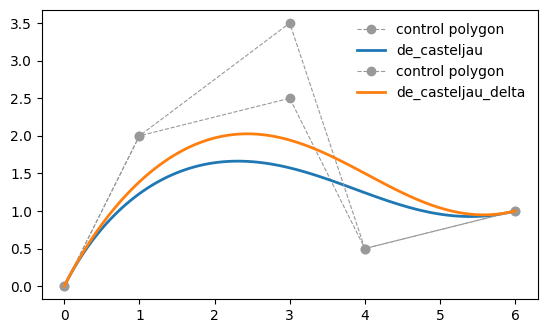

In [2]:
P_bez_ref = np.array([[0., 0.], [1., 2.], [3., 2.5], [4., 0.5], [6., 1.]])

def de_casteljau(P, t):
    P = check_points(P)
    if not (0.0 <= t <= 1.0):
        raise ValueError("t は [0, 1] の範囲が必要です")
    # TODO: 線形補間の繰り返しで C(t) を計算し、(d,) 配列を返す。
    C = P.copy()
    for _ in range(len(P)-1):
        C = (1.0 - t) * C[:-1] + t * C[1:]
    return C[0]

def check_de_casteljau():
    a, b = np.array([1., 2.]), np.array([3., -1.])
    line = np.array([a + b * i / 3 for i in range(4)])   # 直線上に等間隔に並べた制御点
    for t in (0.0, 0.3, 1.0):
        assert np.allclose(de_casteljau(line, t), a + b * t, atol=1e-12, rtol=0)

check_when_ready("演習1", check_de_casteljau)

# TODO: 小問2・3の実験。
t = np.linspace(0, 1, 101)
a = np.array([2.5, -1.0])
s = scale_of(P_bez_ref)
C_dc = np.array([de_casteljau(P_bez_ref, ti) for ti in t])
C_b = np.array([bezier_bernstein(P_bez_ref, ti) for ti in t])
e_b = np.max(np.linalg.norm(C_dc - C_b, axis=1))
assert e_b <= s * 1e-12
C_pa = np.array([de_casteljau(P_bez_ref + a, ti) for ti in t])
e_t = np.max(np.linalg.norm(C_pa - C_dc - a, axis=1))
assert e_t <= s * 1e-12
print("e_b: ", e_b)
print("e_t: ", e_t)

t_eval = np.array([0.05, 0.5, 0.95])
delta = np.zeros_like(P_bez_ref)
delta[2] += np.array([0.0, 1.0])
C_delta = np.array([de_casteljau(P_bez_ref + delta, ti) for ti in t])
dC = np.linalg.norm(C_delta - C_dc, axis=1)
idx = [np.argmin(np.abs(t - ti)) for ti in t_eval]
dC_eval = dC[idx]
print("delta:")
n, i = 4, 2
for j, tj in enumerate(t_eval):
    print(f"  t={tj}: {dC_eval[j]}")
    assert np.abs(dC_eval[j] - comb(n, i) * tj**2 * (1 - tj)**(n - i) * np.linalg.norm(delta[2])) <= 1e-12

ax = plot_curve(P_bez_ref, C_dc, label="de_casteljau")
ax = plot_curve(P_bez_ref + delta, C_delta, label="de_casteljau_delta")
plt.show()

### 演習1 答案

- $e_B$、$e_T$ の値：
  - $e_B = 4.747932766405477\times10^{-15}$
  - $e_T = 7.364386412590296\times10^{-15}$
- $e_T$ がほぼ0になる理由と、Phase 4の剛体並進との対応：
  - 全制御点に $\mathbf a$ を足したとき、de Casteljauのアルゴリズムの右辺は $(1-t)\,(\mathbf P_i^{(r-1)}+\mathbf a)+t\,(\mathbf P_{i+1}^{(r-1)}+\mathbf a)=\mathbf P_i^{(r)}+\mathbf a$ となる。したがって、 $\mathbf C_{\mathbf P+\mathbf a}(t)=\mathbf P_0^{(n)}+\mathbf a=\mathbf C_{\mathbf P}(t)+\mathbf a$ となり、$e_T$ はほぼ0になる。
  - $\sum_i B_{i,n}(t)=1$ と $N_1+N_2=1$ が対応しており、全制御点が定ベクトルだけ動くことと両節点が同量動くことが対応している。
- $t=0.05,\,0.5,\,0.95$ での $\Delta(t)$ と $B_{2,4}(t)\|\boldsymbol\delta\|_2$：
  - $t=0.05,\,0.5,\,0.95$ での $\Delta(t)$ はそれぞれ 0.013537499999999925, 0.375, 0.013537499999999758。
  - $B_{2,4}(t)\|\boldsymbol\delta\|_2$ との差の絶対値は $t=0.05,\,0.5,\,0.95$ で $10^{-12}$ 以下。
- 一つの制御点が曲線全体を動かす理由と、CADでの不便さ：$0<t<1$ で全ての $B_{i,n}>0$ であるため、どの制御点を動かしても曲線全体が動く。これにより曲線を局所的に変更することが難しくなる。

## 演習2：Cox–de Boorの評価器とSTEPの曲線（30点）

**保証する条件**：`U_ref` は $p=3$ の開ノットベクトル $\{0^4,0.3,0.6^2,1^4\}$ で、`P_ref` は2次元の制御点7個。STEPの曲線は本文冒頭の例と同じ。

1. `basis_funs(U, p, u, span)` を実装する。戻り値は長さ $p+1$ の配列 $[N_{\rm span-p,p}(u),\dots,N_{{\rm span},p}(u)]$。本文3節の漸化式を使い、分母が0の項は $0/0=0$ として落とす。全 $n+1$ 個の基底は計算しない。`u` は区間 $[u_{\rm span},u_{{\rm span}+1}]$ の中（**両端を含む**）にあるものとする。右端を含めるのは、演習4で片側極限を評価するためである。（10点）
2. `curve_point(P, U, p, u, span=None)` を実装する。`span` が `None` なら配布の `find_span` で求める。戻り値は `(d,)` 配列。（5点）
3. `U_ref`・`P_ref` について、$u_k=k/200$（$k=0,\dots,200$）で次を確かめ、値を表示する。（10点）
   - 1の分割：$e_{\rm PU}=\max_k|\sum_iN_{i,3}(u_k)-1|\le10^{-12}$。非負性：`basis_funs` が返す全ての値の最小値が $-10^{-14}$ 以上。
   - 局所台：$\mathbf P_2$ だけに $\boldsymbol\delta=(0,1)$ を足し、$\|\mathbf C_{\mathbf P'}(u_k)-\mathbf C_{\mathbf P}(u_k)\|_2>10^{-12}$ となる $u_k$ の最小値と最大値を求める。これを本文の $[u_2,u_6)$ と比べ、演習1-3との違いを1〜2文で述べる。
4. `expand_knots(mults, knots)` を実装し（例：`([2,1,2], [0,0.5,1])` → `[0,0,0.5,1,1]`）、STEPの曲線について `check_knot_vector` を通したうえで $\mathbf C(0)$、$\mathbf C(0.25)$、$\mathbf C(0.5)$、$\mathbf C(1)$ を表示する。曲線が通る制御点と通らない制御点を挙げ、その理由を1文で述べる。（5点）

演習2-1, 2-2: 配布チェック通過
演習2-4: 配布チェック通過
e_pu:  4.440892098500626e-16
basis_funs_min:  0.0
変化したu_kの最小値:  0.005
変化したu_kの最大値:  0.595
C_step(0.0): [0. 0. 0.]
C_step(0.25): [15.     19.6875  0.    ]
C_step(0.5): [30.  22.5  0. ]
C_step(1.0): [60. 20.  0.]


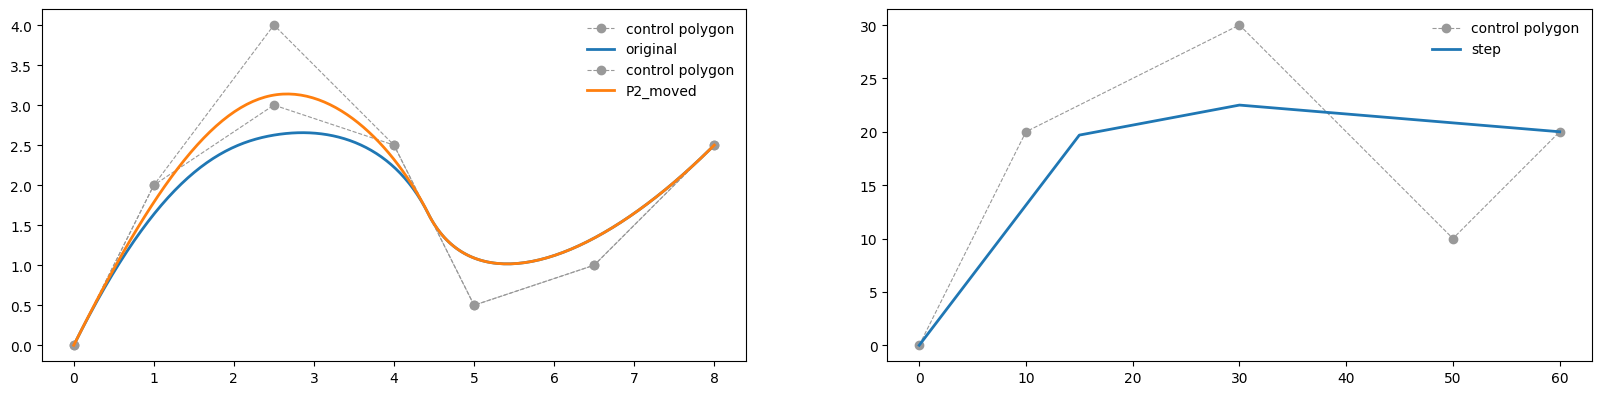

In [3]:
p_ref = 3
U_ref = np.array([0., 0., 0., 0., 0.3, 0.6, 0.6, 1., 1., 1., 1.])
P_ref = np.array([[0., 0.], [1., 2.], [2.5, 3.], [4., 2.5], [5., 0.5], [6.5, 1.], [8., 2.5]])

# 本文冒頭のSTEPの行から読み取った値
p_step_ref = 3
mults_step_ref = [4, 1, 4]
knots_step_ref = [0., 0.5, 1.]
P_step_ref = np.array([[0., 0., 0.], [10., 20., 0.], [30., 30., 0.], [50., 10., 0.], [60., 20., 0.]])

def basis_funs(U, p, u, span):
    U = np.asarray(U, dtype=float)
    if not (p <= span <= len(U) - p - 2) or not (U[span] <= u <= U[span + 1]):
        raise ValueError("span と u の組が不正です")
    # TODO: 長さ p+1 の配列 [N_{span-p,p}(u), ..., N_{span,p}(u)] を返す。
    N = np.zeros(p + 2)
    N[-2] = 1.
    for pi in range(p):
        coef0 = u - U[span - pi - 1:span + 1]
        coef1 = U[span + 1:span + pi + 3] - u
        den0 = U[span:span + pi + 2] - U[span - pi - 1:span + 1]
        den1 = U[span + 1:span + pi + 3] - U[span - pi:span + 2]
        for i in range(pi + 2):
            if np.abs(den0[i]) < 1e-12:
                coef0[i] = 0.
            else:
                coef0[i] /= den0[i]
            if np.abs(den1[i]) < 1e-12:
                coef1[i] = 0.
            else:
                coef1[i] /= den1[i]
        N[-pi - 3:-1] = coef0 * N[-pi - 3:-1] + coef1 * N[-pi - 2:]
    return N[:-1]

def curve_point(P, U, p, u, span=None):
    P = check_points(P)
    U = check_knot_vector(U, p, len(P))
    # TODO: span が None なら find_span で求め、(d,) 配列を返す。
    if span is None:
        span = find_span(U, p, u)
    N = np.zeros(len(P))
    N[span - p:span + 1] = basis_funs(U, p, u, span)
    return N @ P

def expand_knots(mults, knots):
    # TODO: 各ノット値を多重度の回数だけ並べた1次元配列を返す。
    knot_vector = []
    for m, k in zip(mults, knots):
        knot_vector += [k]*m
    return np.array(knot_vector)

def check_basis_and_curve():
    U_bez = [0., 0., 0., 1., 1., 1.]            # 内部ノットなし → Bernstein基底に一致
    assert np.allclose(basis_funs(U_bez, 2, 0.3, 2), [0.49, 0.42, 0.09], atol=1e-12, rtol=0)
    Q = P_bez_ref[:4]
    for t in (0.0, 0.4, 1.0):
        assert np.allclose(curve_point(Q, [0.] * 4 + [1.] * 4, 3, t), bezier_bernstein(Q, t), atol=1e-12, rtol=0)

def check_expand():
    assert np.array_equal(expand_knots([2, 1, 2], [0., 0.5, 1.]), [0., 0., 0.5, 1., 1.])

check_when_ready("演習2-1, 2-2", check_basis_and_curve)
check_when_ready("演習2-4", check_expand)

# TODO: 小問3・4の実験。
u = np.linspace(0., 1., 201)
bf = np.array([basis_funs(U_ref, p_ref, ui, find_span(U_ref, p_ref, ui)) for ui in u])
e_pu = np.max(np.abs(bf.sum(axis=1) - 1.))
print("e_pu: ", e_pu)
assert e_pu <= 1e-12
bf_min = np.min(bf)
print("basis_funs_min: ", bf_min)
assert bf_min >= -1e-14
delta = np.zeros_like(P_ref)
delta[2] += np.array([0.0, 1.0])
C_p = np.array([curve_point(P_ref, U_ref, p_ref, ui) for ui in u])
C_pd = np.array([curve_point(P_ref + delta, U_ref, p_ref, ui) for ui in u])
range_d = np.flatnonzero(np.linalg.norm(C_pd - C_p, axis=1) > 1e-12)
print("変化したu_kの最小値: ", u[range_d[0]])
print("変化したu_kの最大値: ", u[range_d[-1]])

t = np.array([0., 0.25, 0.5, 1.])
U_step = check_knot_vector(expand_knots(mults_step_ref, knots_step_ref), p_step_ref, len(P_step_ref))
C_step = np.array([curve_point(P_step_ref, U_step, p_step_ref, ti) for ti in t])
for i, ti in enumerate(t):
    print(f"C_step({ti}): {C_step[i]}")

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
ax0 = axes[0]
ax0 = plot_curve(P_ref, C_p, ax=ax0, label="original")
ax0 = plot_curve(P_ref + delta, C_pd, ax=ax0, label="P2_moved")
ax1 = axes[1]
ax1 = plot_curve(P_step_ref, C_step, ax=ax1, label="step")
plt.show()

### 演習2 答案

- $e_{\rm PU}$ と基底値の最小値：
  - $e_{\rm PU}=4.440892098500626e-16$
  - 基底値の最小値：0.0
- 局所台：変化した $u_k$ の最小値・最大値、$[u_2,u_6)$ との比較、演習1-3との違い：
  - 変化した $u_k$ の最小値：0.005, 最大値：0.595
  - $[u_2,u_6)=[0,0.6)$ であるが、$u_k$ の刻み幅が0.005であることと、端点は動かないことを考慮すると、上記の結果と一致する。
  - $\mathbf P_2$ の変化は曲線全体にではなく、局所的にしか影響を及ぼさない。
- STEPの曲線の $\mathbf C(0)$、$\mathbf C(0.25)$、$\mathbf C(0.5)$、$\mathbf C(1)$：$\mathbf C(0)=(0, 0, 0)$、$\mathbf C(0.25)=(15, 19.6875, 0)$、$\mathbf C(0.5)=(30, 22.5, 0)$、$\mathbf C(1)=(60, 20, 0)$
- 曲線が通る／通らない制御点とその理由：開ノットベクトルが与えられているとき、曲線は最初と最後の制御点を通るため、曲線が通る制御点は $\mathbf P_0, \mathbf P_4$ であり、それ以外は通らない。

## 演習3：1次B-splineとFEMの形状関数（20点）

**保証する条件**：節点 `x_nodes_ref` $=[0,0.3,0.5,1.0]$ は固体力学Phase 4の非等間隔な1Dバーの節点を想定する。配布の `basis_all` は、演習2の `basis_funs` から全 $n+1$ 個の基底値を並べる補助関数である。

1. 次を $x_k=k/200$（$k=0,\dots,200$）で確かめ、値を表示する。（8点）
   - `U1_ref` $=\{0,0,0.3,0.5,1,1\}$、$p=1$ の基底と、配布の `hat` との一致：$e_{\rm hat}=\max_{i,k}|N_{i,1}(x_k)-{\rm hat}_i(x_k)|\le10^{-12}$。
   - 線形精度：$e_{\rm lin}=\max_k|\sum_iN_{i,1}(x_k)\,x_i-x_k|\le10^{-12}$。
   - 2次の場合：`U2_ref` $=\{0,0,0,0.3,0.5,1,1,1\}$、$p=2$ について、本文4節のGreville点 $\xi_i$ を計算して表示し、$e_{\rm lin2}=\max_k|\sum_iN_{i,2}(x_k)\,\xi_i-x_k|\le10^{-12}$ を確かめる。
2. 1の分割と線形精度が、Phase 4のFEMでそれぞれ何を保証していたかを3〜4文で説明する。キーワード：剛体並進、一定ひずみ、パッチテスト。（6点）
3. $p=1,2,3$ のそれぞれで、内部ノット $\{1/6,2/6,\dots,5/6\}$ をもつ開ノットベクトルを作る。基底 $i$ と $j$ の台 $[u_i,u_{i+p+1})$ と $[u_j,u_{j+p+1})$ が**正の長さで重なる**とき $A_{ij}=1$、それ以外は0とする行列 $\mathbf A$ を作り、各行の非零数の最大値を表示する。この値が $2p+1$ になる理由と、剛性行列 $\mathbf K$ の非零パターンとの関係を2〜3文で述べる。（6点）

In [4]:
x_nodes_ref = np.array([0., 0.3, 0.5, 1.0])
U1_ref = np.array([0., 0., 0.3, 0.5, 1., 1.])
U2_ref = np.array([0., 0., 0., 0.3, 0.5, 1., 1., 1.])

def basis_all(U, p, u):
    """全 n+1 個の基底値 [N_{0,p}(u), ..., N_{n,p}(u)] を返す（配布）。"""
    U = np.asarray(U, dtype=float)
    span = find_span(U, p, u)
    out = np.zeros(len(U) - p - 1)
    out[span - p: span + 1] = basis_funs(U, p, u, span)
    return out

# TODO: 小問1・3の実験。
x = np.linspace(0., 1., 201)
N = np.array([basis_all(U1_ref, 1, xi) for xi in x])
hats = np.array([[hat(x_nodes_ref, i, xi) for i in range(len(U1_ref) - 2)] for xi in x])
e_hat = np.max(np.abs(N - hats))
print("e_hat: ", e_hat)
assert e_hat <= 1e-12
e_lin = np.max(np.abs(N @ x_nodes_ref - x))
print("e_lin: ", e_lin)
assert e_lin <= 1e-12
greville = (U2_ref[1:len(U2_ref) - 2] + U2_ref[2:len(U2_ref) - 1]) / 2.
print("greville: ", greville)
N2 = np.array([basis_all(U2_ref, 2, xi) for xi in x])
e_lin2 = np.max(np.abs(N2 @ greville - x))
print("e_lin2: ", e_lin2)
assert e_lin2 <= 1e-12

knots = [i / 6. for i in range(7)]
for p in range(3):
    p += 1
    n = len(knots) + p - 1
    mults = [p + 1] + [1]*5 + [p + 1]
    U = check_knot_vector(expand_knots(mults, knots), p, n)
    A = np.eye(n)
    for i in range(n - 1):
        for j in range(i + 1, n):
            if U[i + p + 1] > U[j]:
                A[i, j] = A[j, i] = 1.
    print(f"p={p}のときのAの各行の非零数の最大値", np.max(np.array([len(np.flatnonzero(Ai)) for Ai in A])))

e_hat:  1.1102230246251565e-16
e_lin:  5.551115123125783e-17
greville:  [0.   0.15 0.4  0.75 1.  ]
e_lin2:  2.220446049250313e-16
p=1のときのAの各行の非零数の最大値 3
p=2のときのAの各行の非零数の最大値 5
p=3のときのAの各行の非零数の最大値 7


### 演習3 答案

- $e_{\rm hat}$、$e_{\rm lin}$、Greville点 $\xi_i$ と $e_{\rm lin2}$：
  - $e_{\rm hat}=1.1102230246251565e-16$
  - $e_{\rm lin}=5.551115123125783e-17$
  - $\mathbf \xi=(0, 0.15, 0.4, 0.75, 1)$
  - $e_{\rm lin2}=2.220446049250313e-16$
- 1の分割・線形精度とFEMの保証の対応：1の分割は全節点が同じ量動くと剛体並進を表すことを保証している。また、線形精度は線形変位を厳密に表すことを保証している。これは一様変位でひずみゼロ、線形変位で一定ひずみのパッチテストの前提となっている。
- $p=1,2,3$ の行あたり最大非零数、$2p+1$ になる理由、$\mathbf K$ の非零パターンとの関係：
  - 行あたり最大非零数
    - $p=1$: 3
    - $p=2$: 5
    - $p=3$: 7
  - 各基底の台の区間数はそれぞれ $p+1$ であるから、 台が一部重なるパターンの最大数は対称性より $2p$ であり、これに完全に重なるパターン1件を足して、$2p+1$ と求まる。各基底の台の重なりは、剛性行列の同一要素に含まれない節点の組み合わせに対応する成分がゼロになり、帯行列となることに関係する。

## 演習4：多重度と連続性、$C^k$ と $G^k$（20点）

**保証する条件**：`P_k_ref[k]` は、内部ノット $0.5$ の多重度が $k$ の3次曲線 $U=\{0^4,0.5^k,1^4\}$ に対応する制御点。配置は連続性が偶然上がらないように選んである。

1. `derivative_control_points(P, U, p)` を実装する。戻り値は `(Q, U_d, p_d)` で、`Q` は本文5節の $\mathbf Q_i$ を並べた `(n, d)` 配列、`U_d` は両端を1つずつ除いたノットベクトル、`p_d = p-1`。分母が0の $\mathbf Q_i$ は $\mathbf 0$ とする。（6点）
2. $k=1,2,3$ のそれぞれで、$u=0.5$ における $r$ 階導関数（$r=0,1,2,3$。$r=0$ は位置）の左極限 $\mathbf C_L^{(r)}$ と右極限 $\mathbf C_R^{(r)}$ を求め、相対的な跳び
   $$J_r=\frac{\|\mathbf C_L^{(r)}-\mathbf C_R^{(r)}\|_2}{\max(\|\mathbf C_L^{(r)}\|_2,\ \|\mathbf C_R^{(r)}\|_2,\ 1)}$$
   を3行×4列の表にする。$J_r\le10^{-9}$ を「連続」と判定し、各 $k$ で連続だった最高階数を本文の $C^{p-k}$ と比べる。（8点）
   - 片側のスパン番号は配布の `one_sided_spans(U, 0.5)` で得る。
   - ヒント：導関数曲線のノットベクトルは先頭が1つ減るため、同じ区間のスパン番号は微分のたびに1つ小さくなる。
3. $p=1$、$\mathbf P=[(0,0),(1,0),(3,0)]$、$U=\{0,0,0.5,1,1\}$ の曲線について、$u=0.5$ での $\mathbf C'_L$ と $\mathbf C'_R$ を表示し、この曲線が $C^1$ か、$G^1$ かを判定する。CADの「接線連続」が $G^1$ で定義される理由を2〜3文で述べ、$u$ を等間隔に取って曲線上の点を並べると何が起きるかを1文で予想する。（6点）

In [46]:
P_k_ref = {
    1: np.array([[0., 0.], [1., 2.], [3., 3.], [5., 1.], [6., 2.]]),
    2: np.array([[0., 0.], [1., 2.], [2.5, 3.], [4., 1.5], [5., 0.5], [6., 2.]]),
    3: np.array([[0., 0.], [1., 2.], [2., 3.], [3.5, 2.], [4.5, 0.], [5.5, 1.], [6., 2.5]]),
}

def derivative_control_points(P, U, p):
    P = check_points(P)
    U = check_knot_vector(U, p, len(P))
    if p < 1:
        raise ValueError("微分するには次数1以上が必要です")
    # TODO: (Q, U_d, p_d) を返す。
    c = np.array([p / den if den != 0. else 0. for den in U[p + 1:-1] - U[1:len(P)]])
    return np.column_stack([c for _ in range(P.shape[1])]) * (P[1:] - P[:-1]), U[1:-1], p - 1

def check_derivative():
    a, b = np.array([1., 2.]), np.array([3., -1.])
    line = np.array([a + b * i / 3 for i in range(4)])
    Q, U_d, p_d = derivative_control_points(line, [0.] * 4 + [1.] * 4, 3)
    assert p_d == 2 and len(U_d) == 6 and Q.shape == (3, 2)
    for t in (0.0, 0.5, 1.0):   # 直線 a + b t の導関数は一定の b
        assert np.allclose(curve_point(Q, U_d, p_d, t), b, atol=1e-12, rtol=0)

check_when_ready("演習4-1", check_derivative)

# TODO: 小問2・3の実験。
knots = [0., 0.5, 1.]
for k, P in P_k_ref.items():
    mults = [4, k, 4]
    Q = P.copy()
    p = 3
    U = check_knot_vector(expand_knots(mults, knots), p, len(Q))
    span_l, span_r = one_sided_spans(U, 0.5)
    for r in range(4):
        cl = curve_point(Q, U, p, 0.5, span=span_l)
        cr = curve_point(Q, U, p, 0.5, span=span_r)
        print(f"k={k}, J{r}: {np.linalg.norm(cl - cr) / max(np.linalg.norm(cl), np.linalg.norm(cr), 1.)}")
        if p > 0:
            Q, U, p = derivative_control_points(Q, U, p)
            span_l -= 1
            span_r -= 1

p = 1
P = np.array([[0., 0.], [1., 0.], [3., 0.]])
U = [0., 0., 0.5, 1., 1.]
span_l, span_r = one_sided_spans(U, 0.5)
Q, U_d, p_d = derivative_control_points(P, U, p)
cl_d = curve_point(Q, U_d, p_d, 0.5, span=span_l-1)
cr_d = curve_point(Q, U_d, p_d, 0.5, span=span_r-1)
print("C'_L(0.5)= ", cl_d)
print("C'_R(0.5)= ", cr_d)


演習4-1: 配布チェック通過
k=1, J0: 0.0
k=1, J1: 0.0
k=1, J2: 0.0
k=1, J3: 0.7272727272727273
k=2, J0: 0.0
k=2, J1: 0.0
k=2, J2: 0.9468641529479987
k=2, J3: 1.3182203601950573
k=3, J0: 0.0
k=3, J1: 0.5
k=3, J2: 1.674979270186815
k=3, J3: 0.7071067811865476
C'_L(0.5)=  [2. 0.]
C'_R(0.5)=  [4. 0.]


### 演習4 答案

- $J_r$ の表と、$C^{p-k}$ との比較：

| $k$ | $J_0$ | $J_1$ | $J_2$ | $J_3$ | 連続だった最高階数 | 本文の保証 |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 0.0 | 0.0 | 0.0 | 0.7272727272727273 | 2 | $C^2$ |
| 2 | 0.0 | 0.0 | 0.9468641529479987 | 1.3182203601950573 | 1 | $C^1$ |
| 3 | 0.0 | 0.5 | 1.674979270186815 | 0.7071067811865476 | 0 | $C^0$ |

- $\mathbf C'_L(0.5)$、$\mathbf C'_R(0.5)$、$C^1$／$G^1$ の判定：$\mathbf C'_L(0.5)=(2, 0)$、$\mathbf C'_R(0.5)=(4, 0)$、両者の向きは一致しているが大きさは異なるので $G^1$。
- 「接線連続」が $G^1$ で定義される理由：$\mathbf C'(u)$ の大きさはパラメータ$u$が進むときに曲線上を動く速さに対応し、パラメータに依存して変化する。よって、パラメータの定義を変更すると、$\mathbf C^1$ の曲線であっても、その形状を保ったまま $\mathbf C^1$ でなくなることがある。
- $u$ を等間隔に取ったときの予想：勾配が大きなところで点が疎になる。

## 演習5：ノット挿入と形状の同一性（15点）

**保証する条件**：STEPの曲線（演習2と同じ）を使う。挿入するノット $\bar u$ は $0<\bar u<1$ で、挿入後の多重度は $p$ 以下とする。

1. `insert_knot(P, U, p, u_bar)` を実装し、`(P_new, U_new)` を返す。本文6節の式を使う。$\bar u=0.25$ を挿入し、$u_k=k/200$ で $e_{\rm ins}=\max_k\|\mathbf C_{\rm new}(u_k)-\mathbf C_{\rm old}(u_k)\|_2\le10^{-12}s$ を確かめる。挿入前後の制御点を並べて表示する。（7点）
2. 元の曲線に $\bar u=0.5$ を2回挿入して多重度を3にする。形状が変わらないことを小問1と同じ方法で確かめ、演習4の方法で $u=0.5$ の $J_r$（$r=0,\dots,3$）を求める。多重度3の保証（$C^0$）と実際の連続性を比べ、本文の「**少なくとも** $C^{p-k}$」の意味を1〜2文で説明する。（4点）
3. 自動化パイプラインで、パラメータ変更後に再生成した曲線が「前と同じ形状か」を判定したい。（4点）
   - 制御点どうしを比べる判定がなぜ使えないかを、この演習の結果から1文で述べる。
   - 代わりの比較量を**式で**一つ定義する（サンプル点の取り方と、ノルムを明示）。
   - その比較量が前提とする条件を一つ挙げ、前提が崩れる例を1文で述べる。

In [ ]:
def insert_knot(P, U, p, u_bar):
    P = check_points(P)
    U = check_knot_vector(U, p, len(P))
    if not (U[p] < u_bar < U[-p - 1]) or np.count_nonzero(U == u_bar) >= p:
        raise ValueError("u_bar は内部にあり、挿入後の多重度が p 以下である必要があります")
    # TODO: (P_new, U_new) を返す。
    k = find_span(U, p, u_bar)
    ai = (u_bar - U[k - p + 1:k + 1]) / (U[k + 1:k + p + 1] - U[k - p + 1:k + 1])
    ai = np.column_stack([ai for _ in range(P.shape[1])])
    P_new = np.vstack([P[:k - p + 1], ai * P[k - p + 1:k + 1] + (1. - ai) * P[k - p:k], P[k:]])
    return P_new, np.insert(U, k + 1, u_bar)

def check_insert():
    P = np.array([[0., 0.], [1., 1.], [2., 0.]])
    P_new, U_new = insert_knot(P, [0., 0., 0., 1., 1., 1.], 2, 0.5)
    assert P_new.shape == (4, 2) and np.allclose(U_new, [0., 0., 0., 0.5, 1., 1., 1.])
    for u in (0.2, 0.5, 0.9):
        assert np.allclose(curve_point(P_new, U_new, 2, u), curve_point(P, [0.] * 3 + [1.] * 3, 2, u), atol=1e-12, rtol=0)

check_when_ready("演習5-1", check_insert)

# TODO: 小問1・2の実験。
u = np.linspace(0., 1., 201)
U_step = expand_knots(mults_step_ref, knots_step_ref)
P_new, U_new = insert_knot(P_step_ref, U_step, p_step_ref, 0.25)
C_d = np.array([curve_point(P_new, U_new, p_step_ref, ui) - curve_point(P_step_ref, U_step, p_step_ref, ui) for ui in u])
e_ins = np.max(np.linalg.norm(C_d, axis=1))
print("e_ins: ", e_ins)
assert e_ins <= max(scale_of(P_step_ref), scale_of(P_new))*1e-12
print("挿入前制御点: ", P_step_ref)
print("挿入後制御点: ", P_new)

P_new, U_new = P_step_ref.copy(), U_step.copy()
for _ in range(2):
    P_new, U_new = insert_knot(P_new, U_new, p_step_ref, 0.5)
C_d2 = np.array([curve_point(P_new, U_new, p_step_ref, ui) - curve_point(P_step_ref, U_step, p_step_ref, ui) for ui in u])
e_ins2 = np.max(np.linalg.norm(C_d2, axis=1))
print("e_ins2: ", e_ins2)
assert e_ins2 <= max(scale_of(P_step_ref), scale_of(P_new))*1e-12
Q = P_new.copy()
U = U_new.copy()
p = p_step_ref
span_l, span_r = one_sided_spans(U, 0.5)
for r in range(4):
    cl = curve_point(Q, U, p, 0.5, span=span_l)
    cr = curve_point(Q, U, p, 0.5, span=span_r)
    print(f"J{r}: {np.linalg.norm(cl - cr) / max(np.linalg.norm(cl), np.linalg.norm(cr), 1.)}")
    if p > 0:
        Q, U, p = derivative_control_points(Q, U, p)
        span_l -= 1
        span_r -= 1

演習5-1: 配布チェック通過
e_ins:  1.464821375527116e-14
挿入前制御点:  [[ 0.  0.  0.]
 [10. 20.  0.]
 [30. 30.  0.]
 [50. 10.  0.]
 [60. 20.  0.]]
挿入後制御点:  [[ 0.   0.   0. ]
 [ 5.  10.   0. ]
 [15.  22.5  0. ]
 [35.  25.   0. ]
 [50.  10.   0. ]
 [60.  20.   0. ]]
e_ins2:  1.4210854715202004e-14
J0: 0.0
J1: 0.0
J2: 0.0
J3: 0.7272727272727273


### 演習5 答案

- $e_{\rm ins}$ と、挿入前後の制御点：
  - $e_{\rm ins}=1.464821375527116e-14$
  - 挿入前の制御点：$(0, 0, 0), (10, 20, 0), (30, 30, 0), (50, 10, 0), (60, 20, 0)$
  - 挿入後の制御点：$(0, 0, 0), (5, 10, 0), (15, 22.5, 0), (35, 25, 0), (50, 10, 0), (60, 20, 0)$
- 多重度3にした後の $e_{\rm ins}$、$J_r$、「少なくとも」の意味：
  - $e_{\rm ins}=1.4210854715202004e-14$
  - $J_0=0$、$J_1=0$、$J_2=0$、$J_3=0.7272727272727273$
  - 演習4と同じ基準で連続性を判定すると、$C^2$となる。内部ノットを挿入し、多重度を上げても形状は変わらないため、連続性も挿入前の$C^2$と変わらない。
- 制御点どうしの比較が使えない理由：小問1の結果から、制御点が変化しても形状が同じ場合があることがわかる。
- 代わりの比較量（式）：等間隔サンプリングした$u_k$に対して、$\max_k\|\mathbf C_{\rm new}(u_k)-\mathbf C_{\rm old}(u_k)\|_2$。
- その前提と、前提が崩れる例：曲線上のあらゆる点で差を評価できるという前提の比較量だが、曲率の大きな部分があるとサンプリング点が疎になり、そこでの変化を検知できない。

## 振り返り（採点対象外）

解き終えたら、[学習ログ](../../docs/cad/learning-log.md)の「Phase 1初稿」の記入枠に、理解できたこと・つまずいた点・幾何的な直感が持てたか・分量の感想を書いてください。